<div style="text-align:center; markdown=1">
<span style="font-size:12pt">Project Kerja Praktek </span><br>
<span style="font-size:14pt"><b>Prediksi Temperatur Outlet Mill A Unit 3</b></span><br>
Menggunakan Algoritma Adaboost Regressor, Extra Tree Regressor, dan Tensor Flow Keras</div>

<span style="font-size:14pt"><b>Oleh:</b></span><br>
   1. M. Nadhir Al Ghifary 
   2. Ammar Muflih

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import joblib

___

### <span style="font-size:20pt"><b>#1: Pembacaan Data </b></span>

In [2]:
#Buka File
df = pd.read_csv("Datasheet_OutletMill.csv")

___

### <span style="font-size:20pt"><b>#2: Telaah Data </b></span>

#### <b>A. Menampilkan Informasi Dataset</b>

In [3]:
# Menampilkan 9 baris pertama dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2997 entries, 0 to 2996
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date/Time                     2997 non-null   object 
 1    30HFC60CT301.out.sample      2997 non-null   float64
 2    30HFC60CT302.out.sample      2997 non-null   float64
 3    30HFC60AJ001XQ01.out.sample  2997 non-null   float64
 4    30HFB60AF001XQ01.out.sample  2997 non-null   float64
 5    30HHE61CT601.out.sample      2997 non-null   float64
 6    30HHE62CT601.out.sample      2997 non-null   object 
 7    30HHE63CT601.out.sample      2997 non-null   float64
 8    30HHE64CT601.out.sample      2997 non-null   float64
 9    30HFC60CP101.out.sample      2997 non-null   float64
 10   30HFC60CP102.out.sample      2997 non-null   float64
 11   30HFE60CT602.out.sample      2997 non-null   float64
 12   30HFE60CF102_FC.out.sample   2997 non-null   float64
dtypes: 

#### <b>B. Menampilkan Dataset</b>

In [4]:
#Menampilkan 5 data awal dataset
df.head(5)

,Date/Time,30HFC60CT301.out.sample,30HFC60CT302.out.sample,30HFC60AJ001XQ01.out.sample,30HFB60AF001XQ01.out.sample,30HHE61CT601.out.sample,30HHE62CT601.out.sample,30HHE63CT601.out.sample,30HHE64CT601.out.sample,30HFC60CP101.out.sample,30HFC60CP102.out.sample,30HFE60CT602.out.sample,30HFE60CF102_FC.out.sample
0,1/01/2025 00:10:00.0,58.5924,58.8717,37.3758,38.2365,42.3022,45.4175,42.2534,62.2435,1.5655,2.7297,298.7055,70.4342
1,1/01/2025 00:20:00.0,58.5924,58.8717,37.5773,37.0746,42.3022,44.8831,42.2534,62.7650,1.5655,2.7297,298.1960,69.8421
2,1/01/2025 00:30:00.0,58.5924,58.3480,36.0802,34.9266,40.6903,44.8831,41.7165,62.7650,1.5655,2.7297,298.1960,79.3071
3,1/01/2025 00:40:00.0,60.2686,60.5480,36.8814,35.0914,40.1522,44.8831,41.7165,62.7650,1.5655,2.7297,297.0981,81.4614
4,1/01/2025 00:50:00.0,62.5747,62.7495,35.8788,31.7924,40.6903,44.3482,41.7165,62.2435,1.5655,2.7297,295.4897,78.6331


In [5]:
#Menampilkan 5 data terakhir dataset
df.tail(5)

,Date/Time,30HFC60CT301.out.sample,30HFC60CT302.out.sample,30HFC60AJ001XQ01.out.sample,30HFB60AF001XQ01.out.sample,30HHE61CT601.out.sample,30HHE62CT601.out.sample,30HHE63CT601.out.sample,30HHE64CT601.out.sample,30HFC60CP101.out.sample,30HFC60CP102.out.sample,30HFE60CT602.out.sample,30HFE60CF102_FC.out.sample
2992,21/01/2025 18:50:00.0,56.6031,56.7426,-0.0275,-0.0742,36.3241,38.0445,29.7959,43.1120,0.0009,0.1908,109.4160,8.2256
2993,21/01/2025 19:00:00.0,56.6031,56.7426,-0.0275,-0.0742,37.4060,38.5843,29.7959,43.1120,0.0009,0.1908,109.4160,8.2256
2994,21/01/2025 19:10:00.0,56.8473,56.8473,-0.0275,-0.0742,37.8481,38.5843,29.7959,44.3778,0.0009,0.0934,109.6842,8.2761
2995,21/01/2025 19:20:00.0,56.8473,56.8473,-0.0275,-0.0742,37.3078,38.5843,29.7959,44.9612,0.0009,0.0934,109.6842,8.2761
2996,21/01/2025 19:30:00.0,56.8473,56.8473,-0.0275,-0.0742,36.7669,38.5843,29.7959,44.9612,0.0009,0.0934,109.6842,8.2761


Berdasarkan telaah data tersebut, diperlukan perbaikan data sebelum visualiasi dan analisis statistik karena:
1. Terdapat fitur dengan tipe `object`.
2. Nama fitur masih berformat pengalamanatan di DCS.

___

### <span style="font-size:20pt"><b>#3: Perbaikan Data </b></span>

In [6]:
# Ubah kolom tanggal bertipe object menjadi datetime
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format="%d/%m/%Y   %H:%M:%S.%f")

# Ubah kolom bertipe object yang masih tersisa menjadi float
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.replace(',', '.')
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
df = df.rename(columns={
    df.columns[0]: 'Date/Time',
    df.columns[1]: 'OUTLET TEMP 1',
    df.columns[2]: 'OUTLET TEMP 2',
    df.columns[3]: 'MOTOR CURRENT',
    df.columns[4]: 'COAL FEEDER FEEDRATE',
    df.columns[5]: 'A1 PIPE WALL TEMP',
    df.columns[6]: 'A2 PIPE WALL TEMP',
    df.columns[7]: 'A3 PIPE WALL TEMP',
    df.columns[8]: 'A4 PIPE WALL TEMP',
    df.columns[9]: 'GRIND BOWL UP LOW DP',
    df.columns[10]: 'SEAL PA DIFF PRESS',
    df.columns[11]: 'INLET PA TEMP 2',
    df.columns[12]: 'PA FLOW'
})

In [8]:
# Menampilkan Informasi Singkat dari Dataset setelah perubahan tipe variabel
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2997 entries, 0 to 2996
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date/Time             2997 non-null   datetime64[ns]
 1   OUTLET TEMP 1         2997 non-null   float64       
 2   OUTLET TEMP 2         2997 non-null   float64       
 3   MOTOR CURRENT         2997 non-null   float64       
 4   COAL FEEDER FEEDRATE  2997 non-null   float64       
 5   A1 PIPE WALL TEMP     2997 non-null   float64       
 6   A2 PIPE WALL TEMP     2996 non-null   float64       
 7   A3 PIPE WALL TEMP     2997 non-null   float64       
 8   A4 PIPE WALL TEMP     2997 non-null   float64       
 9   GRIND BOWL UP LOW DP  2997 non-null   float64       
 10  SEAL PA DIFF PRESS    2997 non-null   float64       
 11  INLET PA TEMP 2       2997 non-null   float64       
 12  PA FLOW               2997 non-null   float64       
dtypes: datetime64[ns](

In [9]:
df.head(5)

,Date/Time,OUTLET TEMP 1,OUTLET TEMP 2,MOTOR CURRENT,COAL FEEDER FEEDRATE,A1 PIPE WALL TEMP,A2 PIPE WALL TEMP,A3 PIPE WALL TEMP,A4 PIPE WALL TEMP,GRIND BOWL UP LOW DP,SEAL PA DIFF PRESS,INLET PA TEMP 2,PA FLOW
0,2025-01-01 00:10:00,58.5924,58.8717,37.3758,38.2365,42.3022,45.4175,42.2534,62.2435,1.5655,2.7297,298.7055,70.4342
1,2025-01-01 00:20:00,58.5924,58.8717,37.5773,37.0746,42.3022,44.8831,42.2534,62.7650,1.5655,2.7297,298.1960,69.8421
2,2025-01-01 00:30:00,58.5924,58.3480,36.0802,34.9266,40.6903,44.8831,41.7165,62.7650,1.5655,2.7297,298.1960,79.3071
3,2025-01-01 00:40:00,60.2686,60.5480,36.8814,35.0914,40.1522,44.8831,41.7165,62.7650,1.5655,2.7297,297.0981,81.4614
4,2025-01-01 00:50:00,62.5747,62.7495,35.8788,31.7924,40.6903,44.3482,41.7165,62.2435,1.5655,2.7297,295.4897,78.6331


___

### <span style="font-size:20pt"><b>#4: Analisis Statistik Data </b></span>

#### <b>A. Menguji Kekosongan Data</b>

In [10]:
# Menghitung persentase hilang tiap parameter dataset
persentase_datahilang = (df.isnull().sum() / len(df)) * 100

# Menampilkan persentae data hilang tiap parameter dataset
print('Persentase Data Hilang')
persentase_datahilang

Persentase Data Hilang


Date/Time               0.000000
OUTLET TEMP 1           0.000000
OUTLET TEMP 2           0.000000
MOTOR CURRENT           0.000000
COAL FEEDER FEEDRATE    0.000000
A1 PIPE WALL TEMP       0.000000
A2 PIPE WALL TEMP       0.033367
A3 PIPE WALL TEMP       0.000000
A4 PIPE WALL TEMP       0.000000
GRIND BOWL UP LOW DP    0.000000
SEAL PA DIFF PRESS      0.000000
INLET PA TEMP 2         0.000000
PA FLOW                 0.000000
dtype: float64

#### <b>B. Analisis Statistik</b>

In [11]:
# Mengeksplorasi data
df.describe()

,Date/Time,OUTLET TEMP 1,OUTLET TEMP 2,MOTOR CURRENT,COAL FEEDER FEEDRATE,A1 PIPE WALL TEMP,A2 PIPE WALL TEMP,A3 PIPE WALL TEMP,A4 PIPE WALL TEMP,GRIND BOWL UP LOW DP,SEAL PA DIFF PRESS,INLET PA TEMP 2,PA FLOW
count,2997,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,2996.000000,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000
mean,2025-01-11 09:50:00,62.724376,62.567105,35.364201,38.359132,50.061516,47.109433,44.663004,56.240378,1.720429,2.535438,264.477019,76.682936
min,2025-01-01 00:10:00,44.796900,43.198100,-0.036600,-13.086100,28.502500,30.590600,27.306300,35.221200,-0.136400,-0.397000,28.801200,0.000000
25%,2025-01-06 05:00:00,61.421500,61.316600,37.673400,39.596200,49.437000,45.514700,41.960600,50.817100,1.766700,2.556800,267.273100,73.739100
50%,2025-01-11 09:50:00,62.644600,62.434900,39.170500,43.496800,51.702900,47.309100,43.958900,56.911500,1.918000,2.768500,289.321500,87.839200
75%,2025-01-16 14:40:00,63.483600,63.238900,40.466100,45.120200,54.249400,50.016200,47.599600,61.626600,2.038900,2.923400,299.215000,92.573300
max,2025-01-21 19:30:00,132.138400,128.640600,47.443100,48.812000,82.800600,71.032100,75.798400,87.890600,2.520300,7.508500,313.949400,131.128100
std,NaN,3.961047,3.811859,11.997987,13.470411,6.797736,3.840015,5.476369,7.052470,0.591565,0.865371,63.806830,27.203092


#### <b>C. Korelasi Antar Variabel</b>

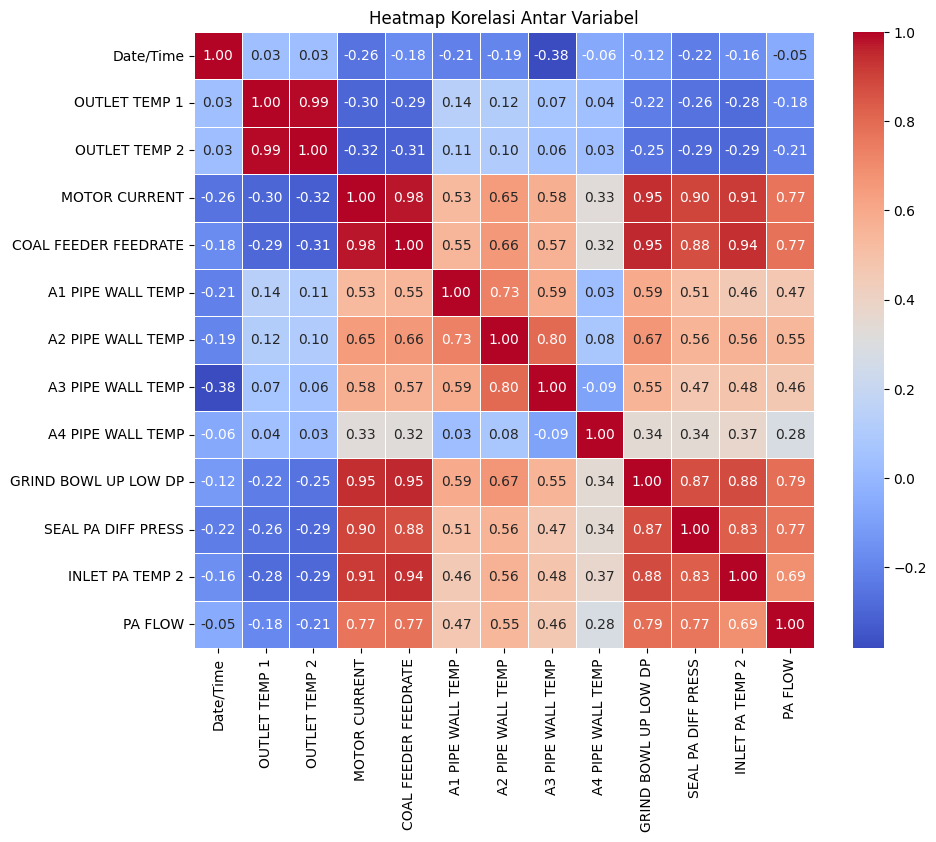

In [12]:
# Hitung matriks korelasi
correlation_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))  # Sesuaikan ukuran jika diperlukan
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

___

### <b>#5: Visualisasi Data </b>

#### <b>A. Boxplot Tiap Variabel</b>

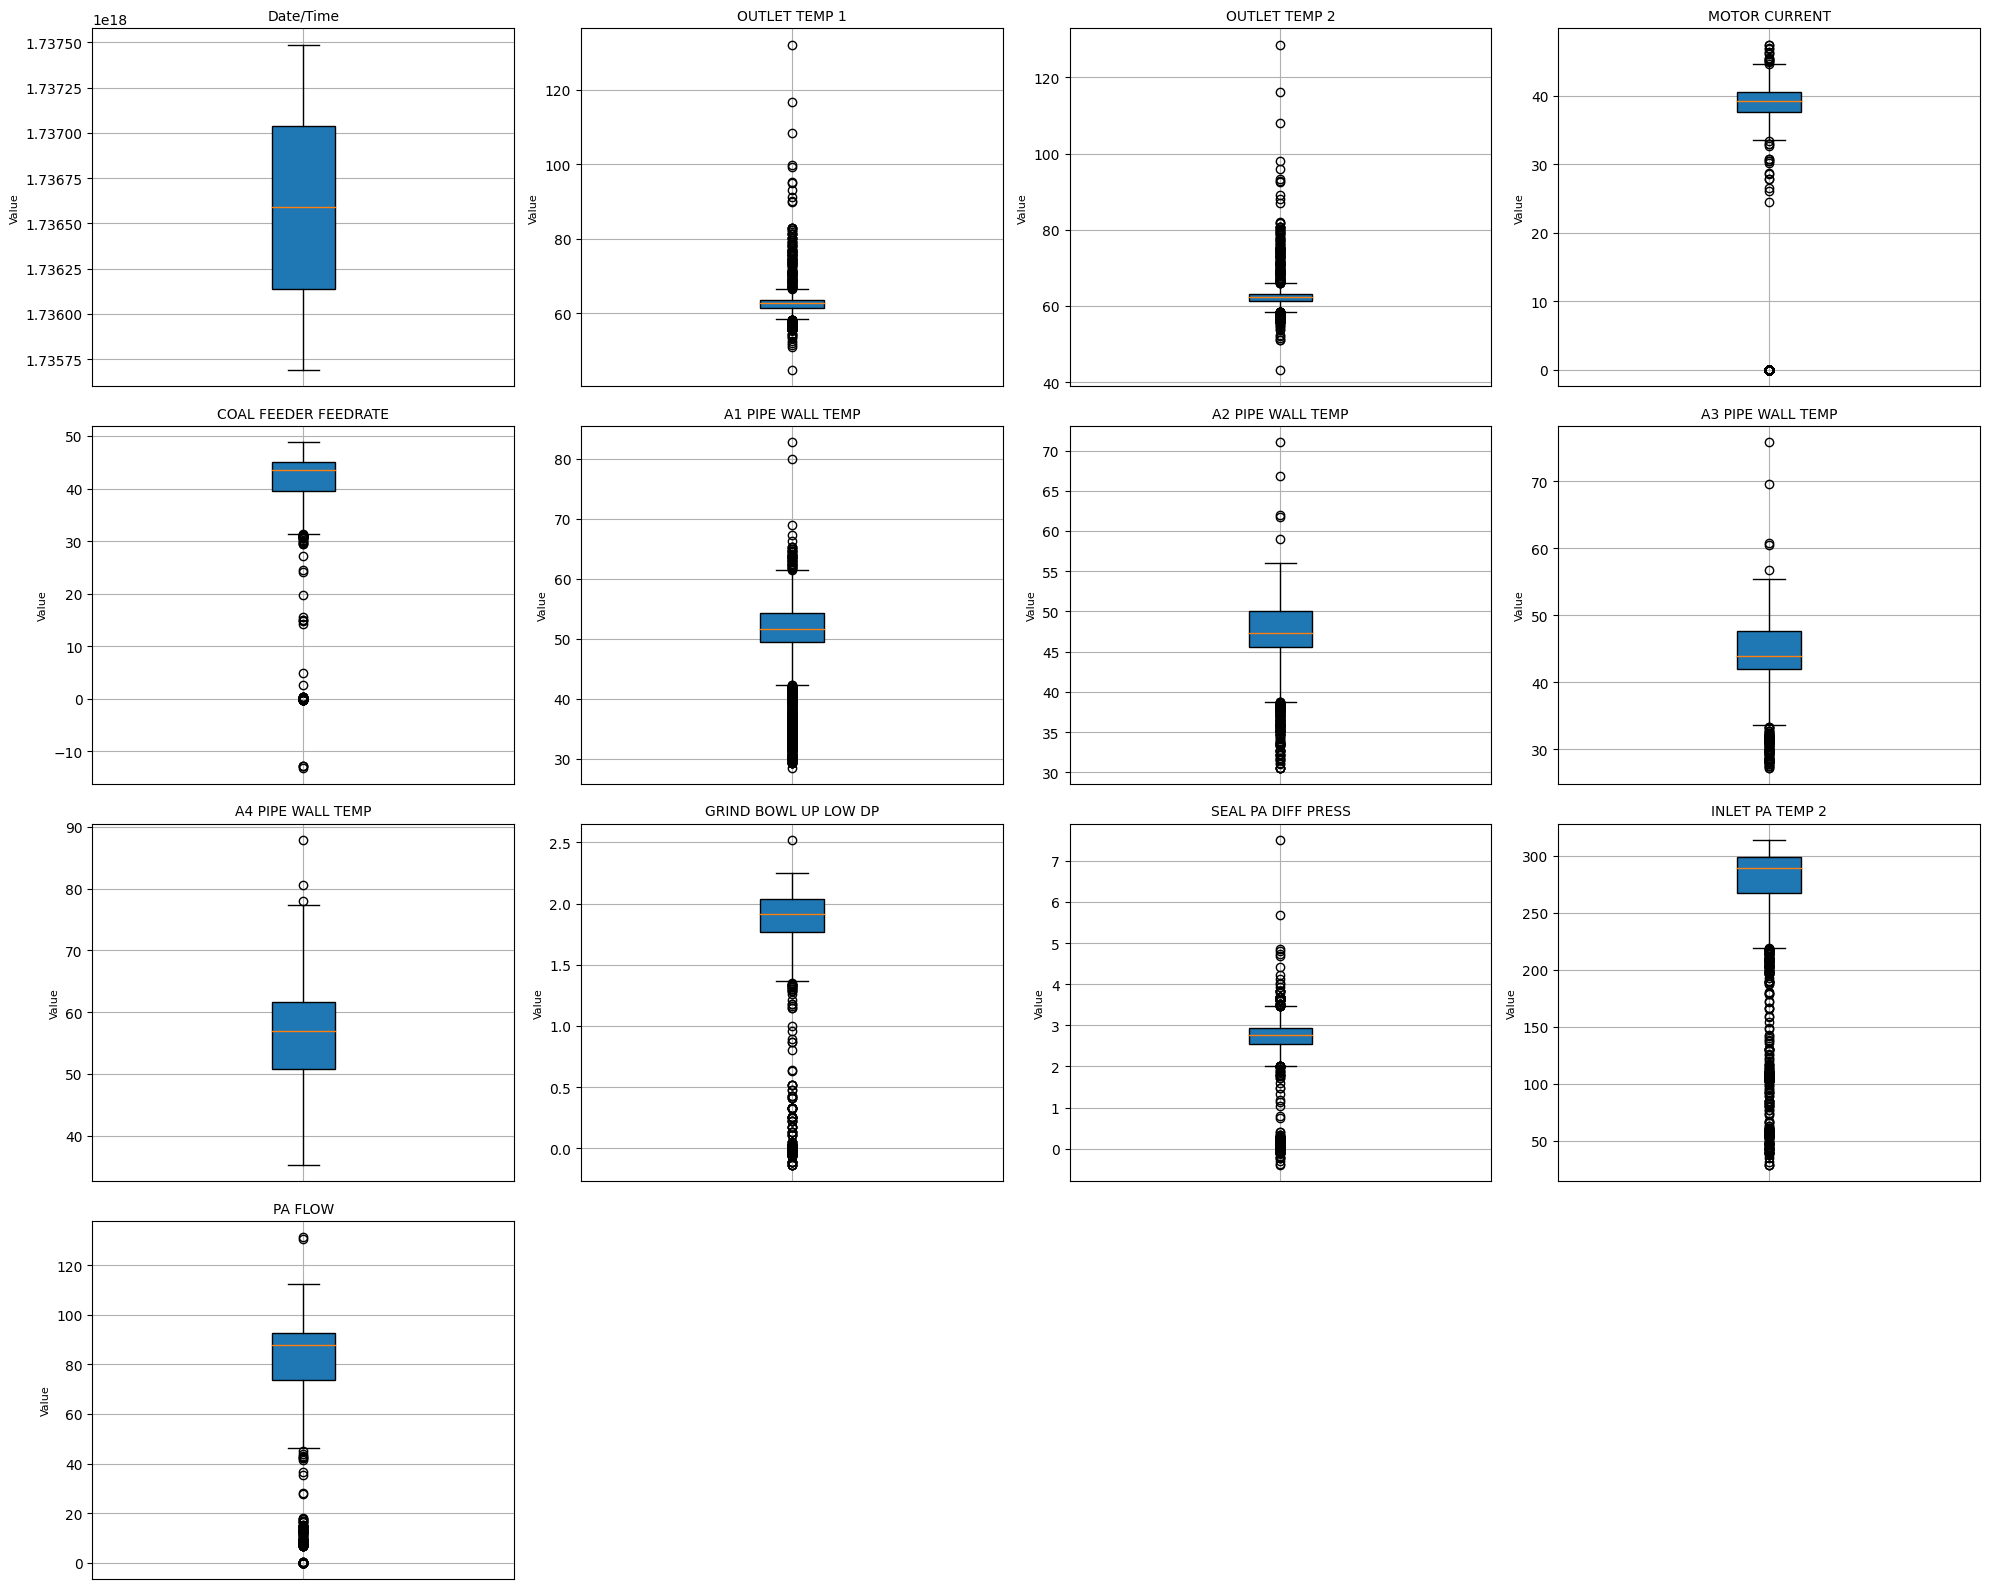

In [13]:
# Exclude the 'date' column and convert all relevant columns to numeric
df_numeric = df.drop(columns=["date"], errors="ignore").apply(pd.to_numeric, errors="coerce")

# Determine non-level and non-airflow columns
individual_columns = [col for col in df_numeric.columns]

# Set the layout (6 rows x 4 columns) for individual columns
num_cols = 4
num_rows = (len(individual_columns) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 16))
axes = axes.flatten()  # Flatten the axes for easy iteration

# Plot individual columns
for i, col in enumerate(individual_columns):
    data = df_numeric[col].dropna()  # Drop NaN values
    axes[i].boxplot(data, patch_artist=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Value", fontsize=8)
    axes[i].grid(True)
    axes[i].tick_params(axis="x", which="both", bottom=False, labelbottom=False)  # Remove x-axis values

# Hide any remaining empty subplots
for j in range(len(individual_columns), len(axes)):
    axes[j].axis('off')

# Adjust layout for the main figure
plt.tight_layout()

# Display all plots
plt.show()

#### <b>B. Histogram Distribusi Temperatur Outlet Mill</b>

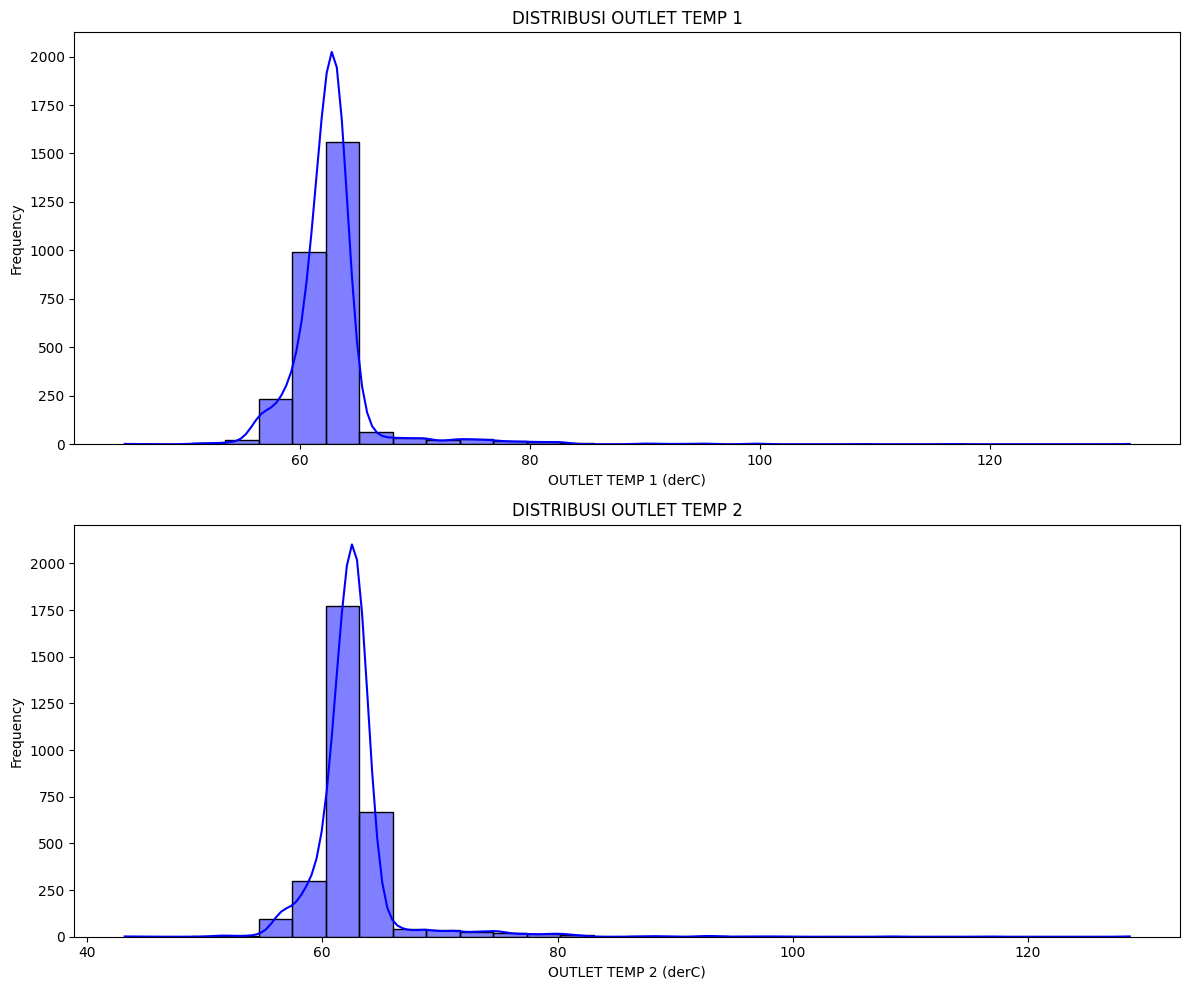

In [14]:
# Define columns to plot (choose any 4 numeric columns)
columns_to_plot = ['OUTLET TEMP 1', 'OUTLET TEMP 2']

# Create a 2E2 layout for the plots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))  # 2E2 grid

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot each column in the 2E2 layout
for i, col in enumerate(columns_to_plot):
    sns.histplot(df_numeric[col].dropna(), kde=True, bins=30, ax=axes[i], color='blue')
    axes[i].set_title(f"DISTRIBUSI {col}", fontsize=12)
    axes[i].set_xlabel(f"{col} (derC)", fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

#### <b>C. Tren Data Temperatur Outlet</b>

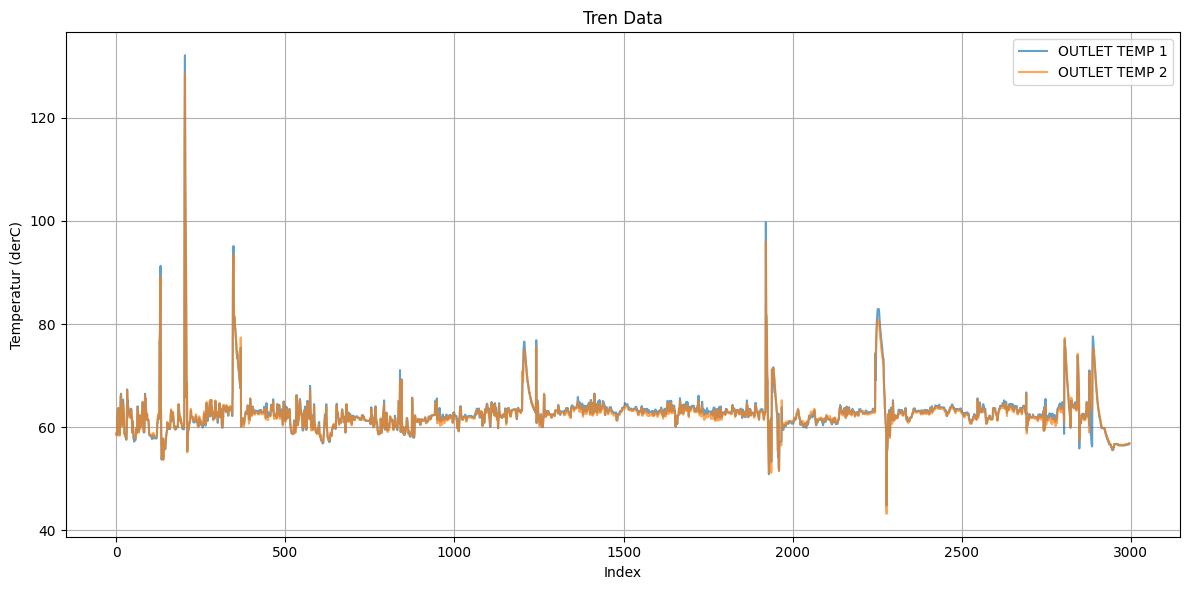

In [15]:
# Memilih kolom yang akan ditampilkan
columns_to_plot = ['OUTLET TEMP 1', 'OUTLET TEMP 2']

# Memeriksa apakah kolom yang diperlukan ada dalam dataset
for col in columns_to_plot:
    if col not in df.columns:
        raise ValueError(f"Kolom '{col}' tidak ditemukan dalam dataset.")

# Membuat grafik tunggal
plt.figure(figsize=(12, 6))
for col in columns_to_plot:
    plt.plot(df.index, df[col], linestyle='-', label=col, alpha=0.7)

# Menambahkan judul dan label
plt.title("Tren Data")
plt.xlabel("Index")
plt.ylabel("Temperatur (derC)")
plt.legend()  # Menampilkan legenda untuk setiap kolom
plt.grid(True)  # Menambahkan grid untuk memudahkan pembacaan

# Menampilkan plot
plt.tight_layout()
plt.show()

___

### <b>#6: Pre Processing Data </b>

#### <b>A. Membuang Data Untuk Baris Kosong </b>

In [16]:
# Menemukan baris yang memiliki nilai kosong di kolom "A2 PIPE WALL TEMP"
missing_rows = df[df["A2 PIPE WALL TEMP"].isna()]
df = df.dropna(subset=["A2 PIPE WALL TEMP"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2996 entries, 0 to 2996
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date/Time             2996 non-null   datetime64[ns]
 1   OUTLET TEMP 1         2996 non-null   float64       
 2   OUTLET TEMP 2         2996 non-null   float64       
 3   MOTOR CURRENT         2996 non-null   float64       
 4   COAL FEEDER FEEDRATE  2996 non-null   float64       
 5   A1 PIPE WALL TEMP     2996 non-null   float64       
 6   A2 PIPE WALL TEMP     2996 non-null   float64       
 7   A3 PIPE WALL TEMP     2996 non-null   float64       
 8   A4 PIPE WALL TEMP     2996 non-null   float64       
 9   GRIND BOWL UP LOW DP  2996 non-null   float64       
 10  SEAL PA DIFF PRESS    2996 non-null   float64       
 11  INLET PA TEMP 2       2996 non-null   float64       
 12  PA FLOW               2996 non-null   float64       
dtypes: datetime64[ns](1), f

#### <b>B. Membuang Data Saat Mill Tidak Beroperasi </b>

In [17]:
# Menemukan baris di mana "MOTOR CURRENT" < 3
df = df[df["MOTOR CURRENT"] >= 3]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2694 entries, 0 to 2877
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date/Time             2694 non-null   datetime64[ns]
 1   OUTLET TEMP 1         2694 non-null   float64       
 2   OUTLET TEMP 2         2694 non-null   float64       
 3   MOTOR CURRENT         2694 non-null   float64       
 4   COAL FEEDER FEEDRATE  2694 non-null   float64       
 5   A1 PIPE WALL TEMP     2694 non-null   float64       
 6   A2 PIPE WALL TEMP     2694 non-null   float64       
 7   A3 PIPE WALL TEMP     2694 non-null   float64       
 8   A4 PIPE WALL TEMP     2694 non-null   float64       
 9   GRIND BOWL UP LOW DP  2694 non-null   float64       
 10  SEAL PA DIFF PRESS    2694 non-null   float64       
 11  INLET PA TEMP 2       2694 non-null   float64       
 12  PA FLOW               2694 non-null   float64       
dtypes: datetime64[ns](1), f

#### <b>D. Menghapus Outlier </b>

In [18]:
# Tentukan kolom yang bukan Date/Time
numerical_cols = df.select_dtypes(include=[np.number]).columns  # Hanya kolom numerik

# Menggunakan metode IQR untuk mendeteksi dan menghapus outlier
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter data untuk menghapus outlier
df_cleaned = df[~((df[numerical_cols] < lower_bound) | (df[numerical_cols] > upper_bound)).any(axis=1)]

# Menampilkan hasil
print("Jumlah data sebelum menghapus outlier:", df.shape[0])
print("Jumlah data setelah menghapus outlier:", df_cleaned.shape[0])

Jumlah data sebelum menghapus outlier: 2694
Jumlah data setelah menghapus outlier: 1868


___

### <b>#7: Visualisasi Final </b>

#### <b>A. Menampilkan Ulang Tren Data </b>

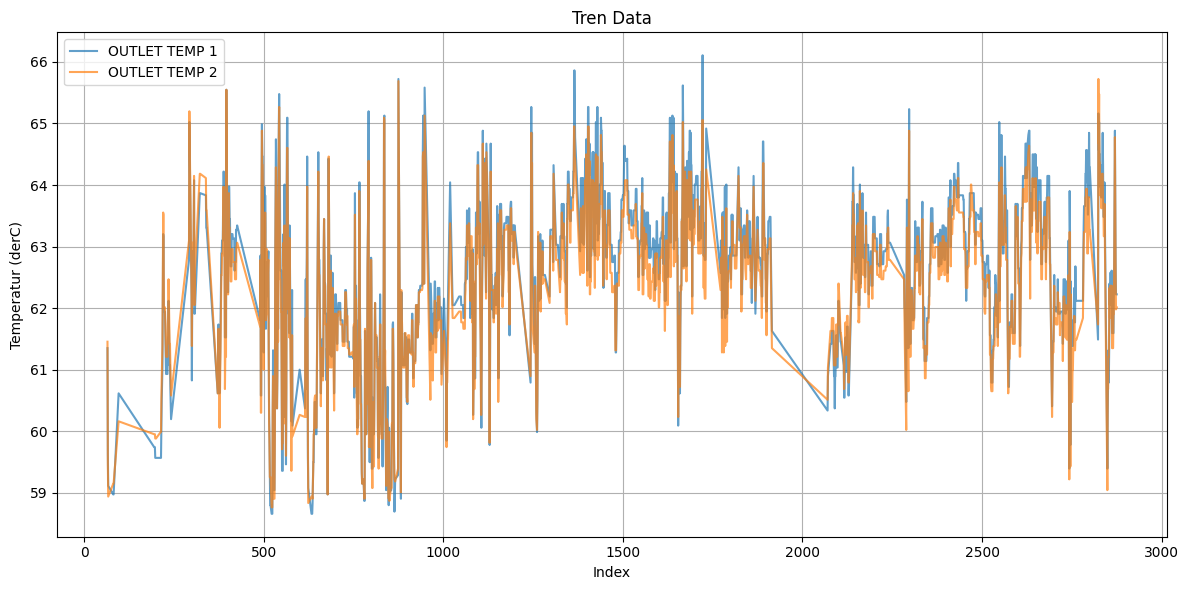

In [19]:
df = df_cleaned

# Memilih kolom yang akan ditampilkan
columns_to_plot = ['OUTLET TEMP 1', 'OUTLET TEMP 2']

# Memeriksa apakah kolom yang diperlukan ada dalam dataset
for col in columns_to_plot:
    if col not in df.columns:
        raise ValueError(f"Kolom '{col}' tidak ditemukan dalam dataset.")

# Membuat grafik tunggal
plt.figure(figsize=(12, 6))
for col in columns_to_plot:
    plt.plot(df.index, df[col], linestyle='-', label=col, alpha=0.7)

# Menambahkan judul dan label
plt.title("Tren Data")
plt.xlabel("Index")
plt.ylabel("Temperatur (derC)")
plt.legend()  # Menampilkan legenda untuk setiap kolom
plt.grid(True)  # Menambahkan grid untuk memudahkan pembacaan

# Menampilkan plot
plt.tight_layout()
plt.show()

#### <b>B. Menampilkan Ulang Histogram Distribusi Temperatur Outlet Mill</b>

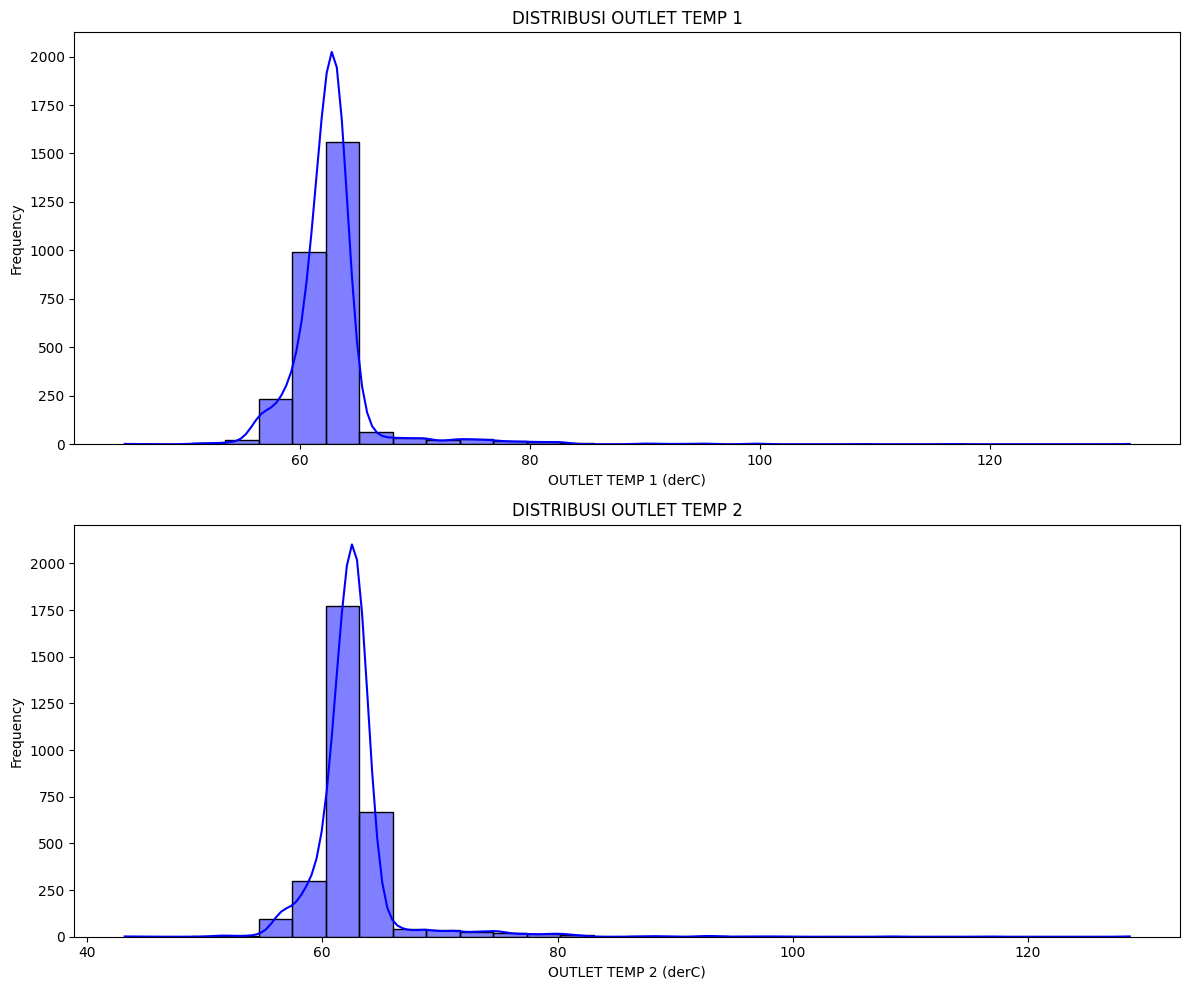

In [20]:
# Define columns to plot (choose any 4 numeric columns)
columns_to_plot = ['OUTLET TEMP 1', 'OUTLET TEMP 2']

# Create a 2E2 layout for the plots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))  # 2E2 grid

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot each column in the 2E2 layout
for i, col in enumerate(columns_to_plot):
    sns.histplot(df_numeric[col].dropna(), kde=True, bins=30, ax=axes[i], color='blue')
    axes[i].set_title(f"DISTRIBUSI {col}", fontsize=12)
    axes[i].set_xlabel(f"{col} (derC)", fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

#### <b>C. Menampilkan Box Plot Ulang Setelah Penghapusan Outlier</b>

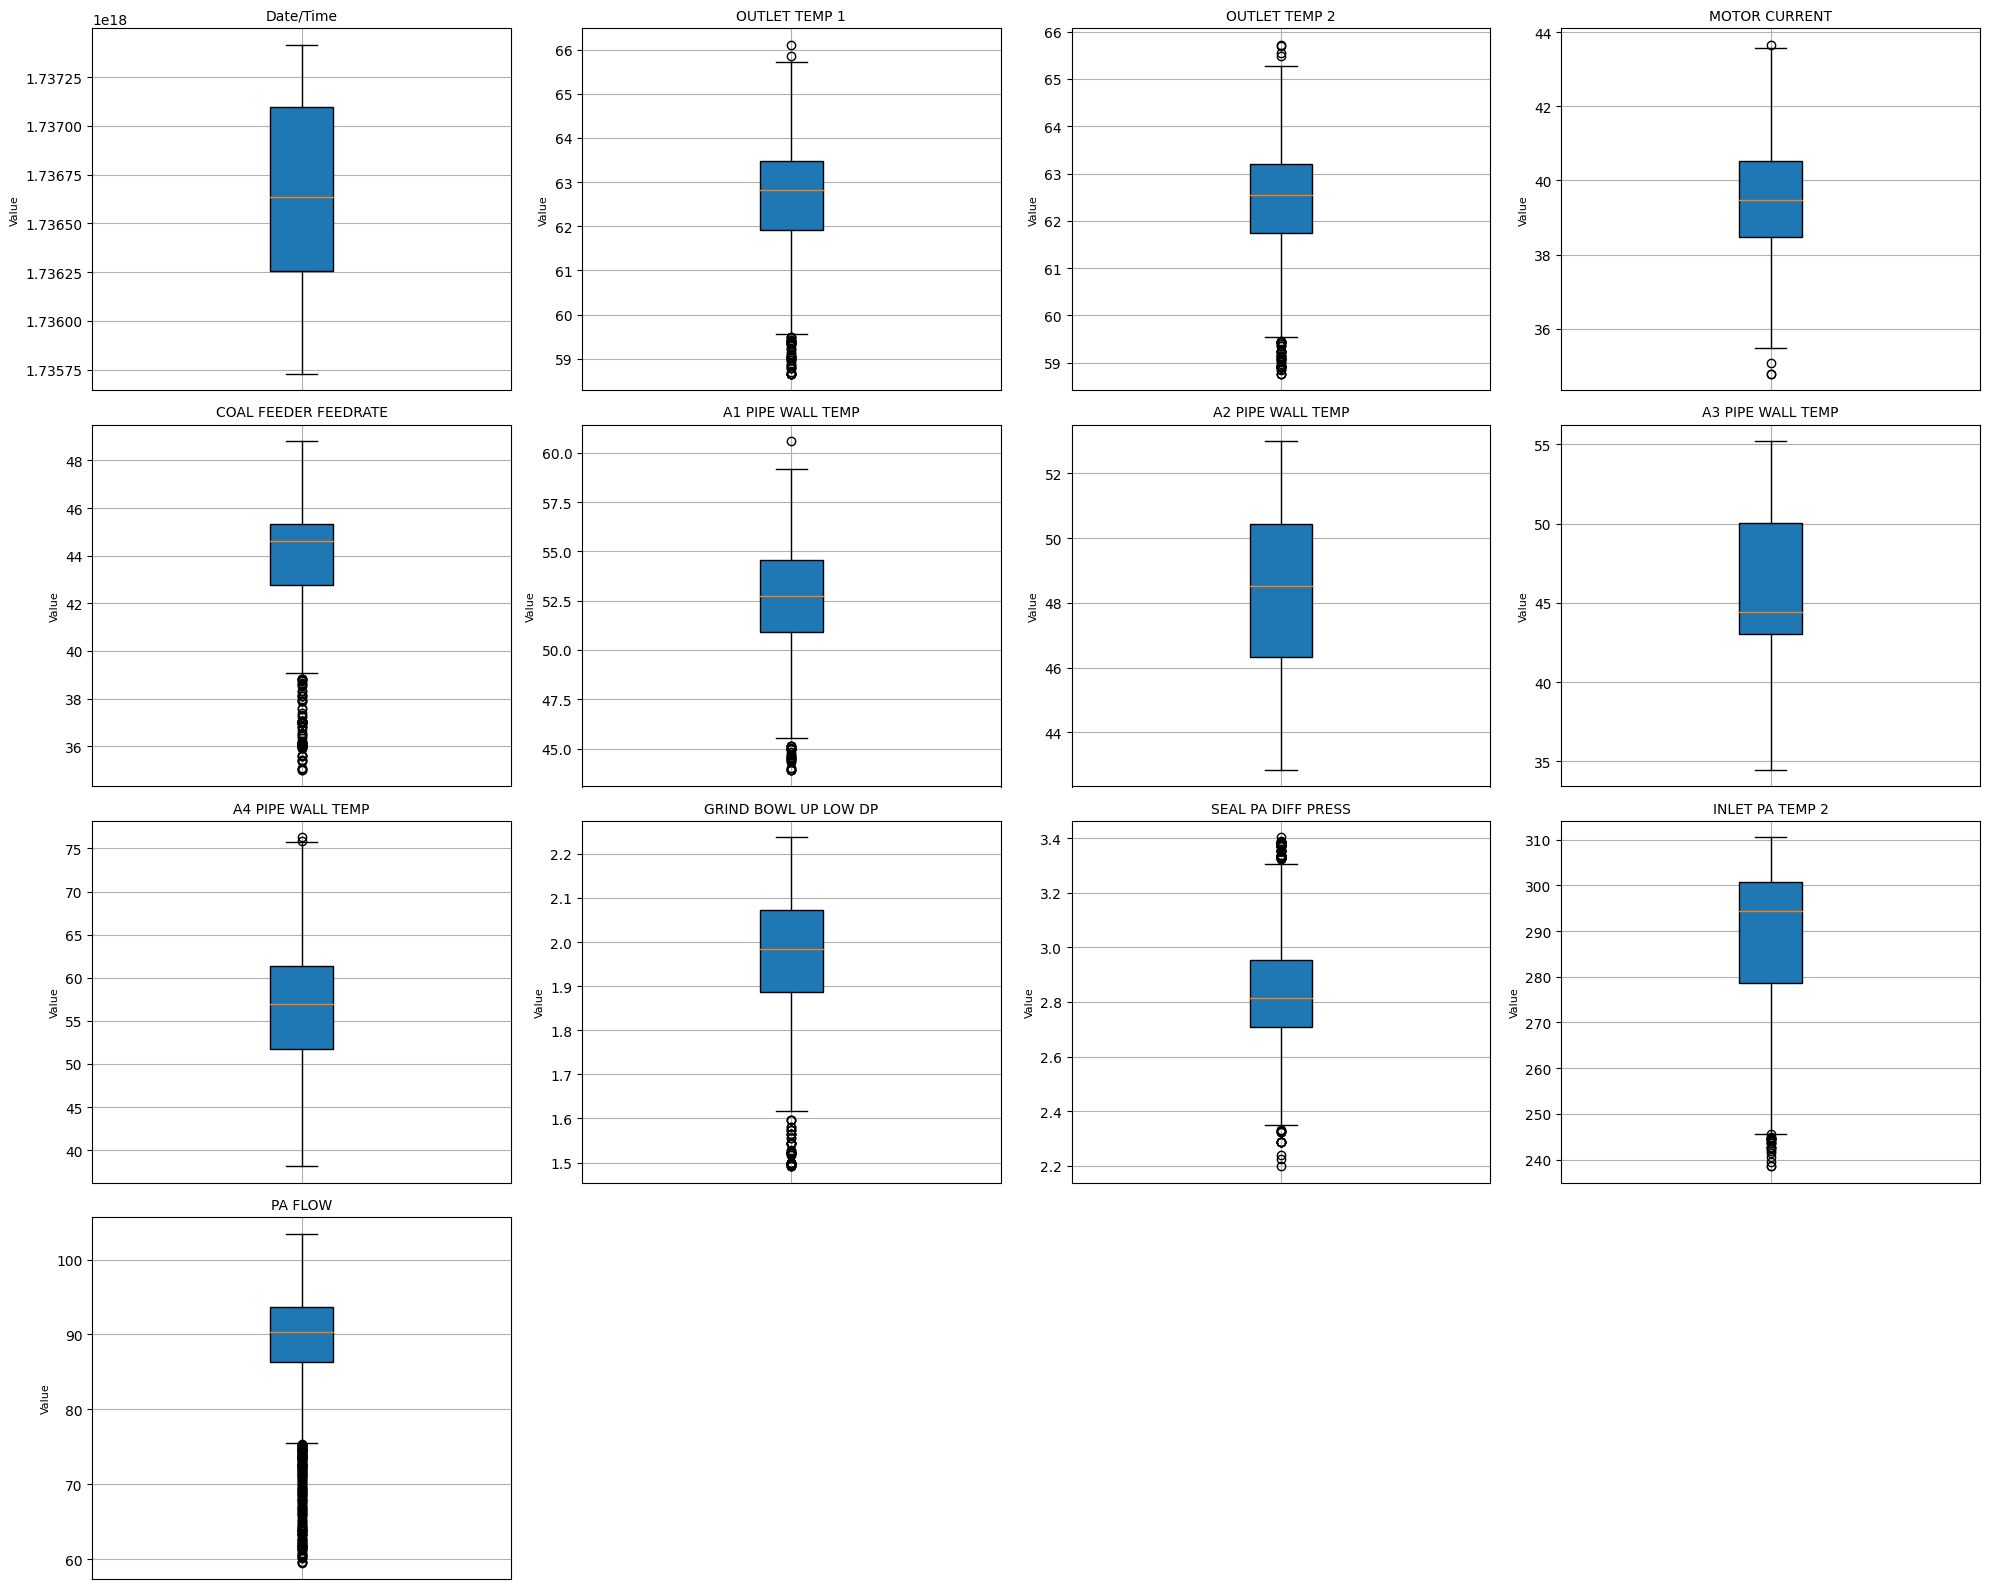

In [21]:
# Exclude the 'date' column and convert all relevant columns to numeric
df_numeric = df.drop(columns=["date"], errors="ignore").apply(pd.to_numeric, errors="coerce")

# Determine non-level and non-airflow columns
individual_columns = [col for col in df_numeric.columns]

# Set the layout (6 rows x 4 columns) for individual columns
num_cols = 4
num_rows = (len(individual_columns) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 16))
axes = axes.flatten()  # Flatten the axes for easy iteration

# Plot individual columns
for i, col in enumerate(individual_columns):
    data = df_numeric[col].dropna()  # Drop NaN values
    axes[i].boxplot(data, patch_artist=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Value", fontsize=8)
    axes[i].grid(True)
    axes[i].tick_params(axis="x", which="both", bottom=False, labelbottom=False)  # Remove x-axis values

# Hide any remaining empty subplots
for j in range(len(individual_columns), len(axes)):
    axes[j].axis('off')

# Adjust layout for the main figure
plt.tight_layout()

# Display all plots
plt.show()

#### <b>D. Menghitung Ulang Korelasi Antar Variabel </b>

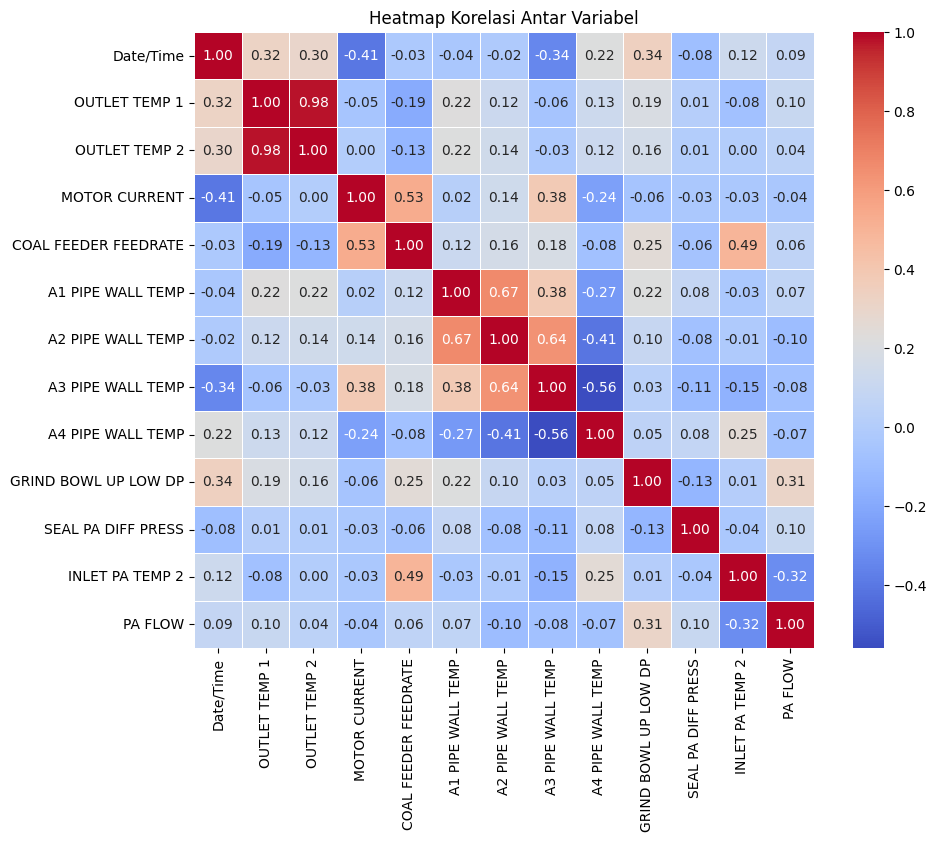

In [22]:
# Hitung matriks korelasi
correlation_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))  # Sesuaikan ukuran jika diperlukan
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

___

### <b>#8: Feature Engineering </b>

#### <b>A. Membangi Data Train, Data Test, dan Data Validasi </b>

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

# Drop kolom yang tidak digunakan
columns_to_drop = ['Date/Time', 'OUTLET TEMP 2']
data = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Memisahkan fitur (X) dan target (y)
X = data.drop(columns=['OUTLET TEMP 1'])  # Ganti dengan nama kolom target yang tepat
y = data['OUTLET TEMP 1']

# Membagi dataset menjadi training dan testing set
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)  # 70% train, 30% lainnya
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 15% val, 15% test

#### <b>B. Standarization </b>

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

___

### <b>#9: Model Building </b>

#### <b>A. Metode Pemrograman Python</b>

#### <u> Adaboost Regressor - Decission Tree Regressor</u>

In [25]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Definisi base estimator
base_estimator = DecisionTreeRegressor()

# Inisialisasi model AdaBoost dengan base estimator
adaboost = AdaBoostRegressor(base_estimator=base_estimator, random_state=42)

# Daftar parameter untuk dicoba
param_dist = {
    "n_estimators": np.arange(20, 1000, 10),
    "learning_rate": np.logspace(-3, 0, 10),
    "base_estimator__max_depth": np.arange(1, 15)
}

# Randomized Search
random_search = RandomizedSearchCV(adaboost, param_distributions=param_dist, n_iter=20, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

# Hasil tuning
print("Best Parameters:", random_search.best_params_)
print("Best Score:", -random_search.best_score_)
print(20*'-')

# Model terbaik
best_model_adaboost = random_search.best_estimator_

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Prediksi pada data test
y_test_pred = best_model_adaboost.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f'Test MSE: {mse_test:.4f}')
print(f'Test MAE: {mae_test:.4f}')
print(f'Test R2 Score: {r2_test:.4f}')
print(20*'-')

# Prediksi pada data validasi
y_val_pred = best_model_adaboost.predict(X_val)
mse_val = mean_squared_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)

print(f'Validation MSE: {mse_val:.4f}')
print(f'Validation MAE: {mae_val:.4f}')
print(f'Validation R2 Score: {r2_val:.4f}')

joblib.dump(best_model_adaboost, "Adaboost_Best.pkl")

Best Parameters: {'n_estimators': 920, 'learning_rate': 0.1, 'base_estimator__max_depth': 14}
Best Score: 0.628803475190582
--------------------
Test MSE: 0.3125
Test MAE: 0.3789
Test R2 Score: 0.7481
--------------------
Validation MSE: 0.4535
Validation MAE: 0.4407
Validation R2 Score: 0.7012


['Adaboost_Best.pkl']

#### <u> Extra Tree Regressor</u>

In [26]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Model dasar
extra_trees = ExtraTreesRegressor(random_state=42)

# Parameter yang akan dicari
param_dist = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Randomized Search dengan CV = 5 (5-fold cross-validation)
random_search = RandomizedSearchCV(
    extra_trees, 
    param_distributions=param_dist, 
    n_iter=10,       # Jumlah kombinasi yang diuji
    cv=5,            # 5-fold cross-validation
    scoring="neg_mean_squared_error", 
    n_jobs=-1, 
    random_state=42
)
random_search.fit(X_train, y_train)

# Hasil tuning
print("Best Parameters:", random_search.best_params_)
print("Best Score:", -random_search.best_score_)
print(20*"-")

# Model terbaik
best_model_extratree = random_search.best_estimator_

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Prediksi pada data test
y_test_pred = best_model_extratree.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f'Test MSE: {mse_test:.4f}')
print(f'Test MAE: {mae_test:.4f}')
print(f'Test R2 Score: {r2_test:.4f}')
print(20*"-")

# Prediksi pada data validasi
y_val_pred = best_model_extratree.predict(X_val)
mse_val = mean_squared_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)

print(f'Validation MSE: {mse_val:.4f}')
print(f'Validation MAE: {mae_val:.4f}')
print(f'Validation R2 Score: {r2_val:.4f}')

joblib.dump(best_model_extratree, "ExtraTree_Best.pkl")

Best Parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best Score: 0.5796063828684133
--------------------
Test MSE: 0.2874
Test MAE: 0.3877
Test R2 Score: 0.7683
--------------------
Validation MSE: 0.4349
Validation MAE: 0.4535
Validation R2 Score: 0.7135


['ExtraTree_Best.pkl']

#### <u> Tensor Flow Keras</u>

c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 3746.0295 - mae: 61.1506 - val_loss: 2411.1692 - val_mae: 48.9619
Epoch 2/300
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1541.8054 - mae: 36.7118 - val_loss: 135.3924 - val_mae: 9.5053
Epoch 3/300
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 195.4010 - mae: 11.2445 - val_loss: 103.3078 - val_mae: 8.2514
Epoch 4/300
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 171.8135 - mae: 10.6344 - val_loss: 91.4216 - val_mae: 7.7441
Epoch 5/300
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 161.8768 - mae: 10.1719 - val_loss: 80.1024 - val_mae: 7.1735
Epoch 6/300
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 145.9285 - mae: 9.6009 - val_loss: 73.1263 - val_mae: 6.9295
Epoch 7/300
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 129.1799 - mae: 9.1058 - val_loss: 67.2233 - val_mae: 6.5813
Epoch 8/300
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 136.0524 - mae: 9.3153 - val_loss: 62.5341 - val_mae: 6.3306
Epoch 9/300
82/82 ━━━━━━━━

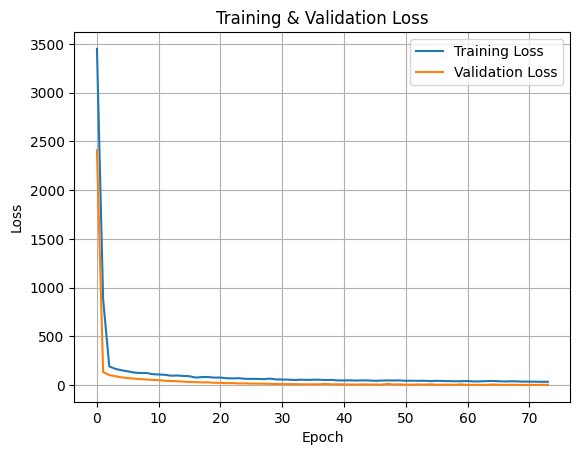

In [27]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras

# Model dengan regularisasi & dropout lebih tinggi untuk mencegah overfitting
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001), input_shape=(X_train.shape[1],)),
    keras.layers.Dropout(0.3),  # Dropout lebih besar untuk mengurangi overfitting
    keras.layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

# Optimizer dengan learning rate lebih kecil
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

# Compile model
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Early stopping lebih ketat
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

# Train model dengan batch size berbeda
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=16,  # Batch size lebih kecil untuk lebih stabil
    callbacks=[early_stopping],    
    verbose=1
)

# Plot loss curve
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid()
plt.show()

#### <u> Feature Importance via Adaboost Regressor - Decission Tree</u>

                Feature  Importance
1  COAL FEEDER FEEDRATE    0.183031
2     A1 PIPE WALL TEMP    0.111265
6  GRIND BOWL UP LOW DP    0.106805
5     A4 PIPE WALL TEMP    0.099071
3     A2 PIPE WALL TEMP    0.097852
7    SEAL PA DIFF PRESS    0.095338
0         MOTOR CURRENT    0.085343
4     A3 PIPE WALL TEMP    0.076179
9               PA FLOW    0.073986
8       INLET PA TEMP 2    0.071129


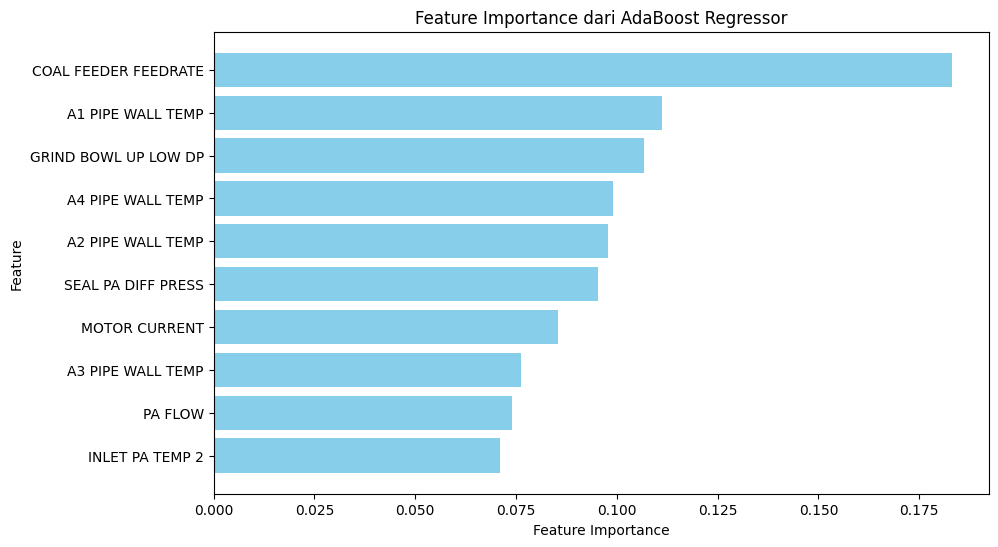

In [28]:
# Ambil nama fitur asli dari DataFrame sebelum dikonversi ke array
feature_names = X.columns  # X masih berbentuk DataFrame sebelum diubah ke array

# Ambil feature importances dari model terbaik
feature_importances = best_model_adaboost.feature_importances_

# Buat DataFrame untuk menampilkan fitur dan kepentingannya
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

# Tampilkan hasil dalam bentuk tabel
print(feature_importance_df)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"], color='skyblue')
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance dari AdaBoost Regressor")
plt.gca().invert_yaxis()  # Membalikkan urutan agar fitur terpenting ada di atas
plt.show()

#### <b>B. Metode Excel</b>

#### <u> Symbolic Regressor</u>

In [29]:
df_baru = pd.read_csv("Datasheet_OutletMill.csv")

# Ubah kolom tanggal bertipe object menjadi datetime
df_baru['Date/Time'] = pd.to_datetime(df_baru['Date/Time'], format="%d/%m/%Y   %H:%M:%S.%f")

# Ubah kolom bertipe object yang masih tersisa menjadi float
for col in df_baru.select_dtypes(include='object').columns:
    df_baru[col] = df_baru[col].str.replace(',', '.')
    df_baru[col] = pd.to_numeric(df_baru[col], errors='coerce')

df_baru = df_baru.rename(columns={
    df_baru.columns[0]: 'Date/Time',
    df_baru.columns[1]: 'OUTLET TEMP 1',
    df_baru.columns[2]: 'OUTLET TEMP 2',
    df_baru.columns[3]: 'MOTOR CURRENT',
    df_baru.columns[4]: 'COAL FEEDER FEEDRATE',
    df_baru.columns[5]: 'A1 PIPE WALL TEMP',
    df_baru.columns[6]: 'A2 PIPE WALL TEMP',
    df_baru.columns[7]: 'A3 PIPE WALL TEMP',
    df_baru.columns[8]: 'A4 PIPE WALL TEMP',
    df_baru.columns[9]: 'GRIND BOWL UP LOW DP',
    df_baru.columns[10]: 'SEAL PA DIFF PRESS',
    df_baru.columns[11]: 'INLET PA TEMP 2',
    df_baru.columns[12]: 'PA FLOW'
})

# Menemukan baris yang memiliki nilai kosong di kolom "A2 PIPE WALL TEMP"
missing_rows = df_baru[df_baru["A2 PIPE WALL TEMP"].isna()]
df_baru = df_baru.dropna(subset=["A2 PIPE WALL TEMP"])

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gplearn.genetic import SymbolicRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [31]:
# Asumsikan df adalah DataFrame yang sudah dibaca
X = df_baru.drop(columns=["Date/Time", "OUTLET TEMP 1", "OUTLET TEMP 2"])  # Menghapus fitur yang tidak digunakan
y = df_baru["OUTLET TEMP 1"]

# Bagi dataset menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
# Inisialisasi model Symbolic Regression
model = SymbolicRegressor(
    population_size=1000,  # Jumlah kandidat persamaan dalam populasi
    generations=20,  # Jumlah iterasi evolusi
    function_set=('add', 'sub', 'mul', 'div', 'sqrt', 'log', 'sin', 'cos', 'tan'),  # Operator yang digunakan
    metric='mse',  # Menggunakan Mean Squared Error sebagai metrik
    random_state=42,
    n_jobs=-1  # Gunakan semua core CPU untuk training lebih cepat
)

# Training model
model.fit(X_train, y_train)

SymbolicRegressor(function_set=('add', 'sub', 'mul', 'div', 'sqrt', 'log',
                                'sin', 'cos', 'tan'),
                  metric='mse', n_jobs=-1, random_state=42)

In [33]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.4f}")

Test MSE: 17.3551


___

### <b>#10: Penerapan Model </b>

#### <b>A. Adaboost Regressor - Decission Tree</b>

c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but AdaBoostRegressor was fitted without feature names
  warnings.warn(


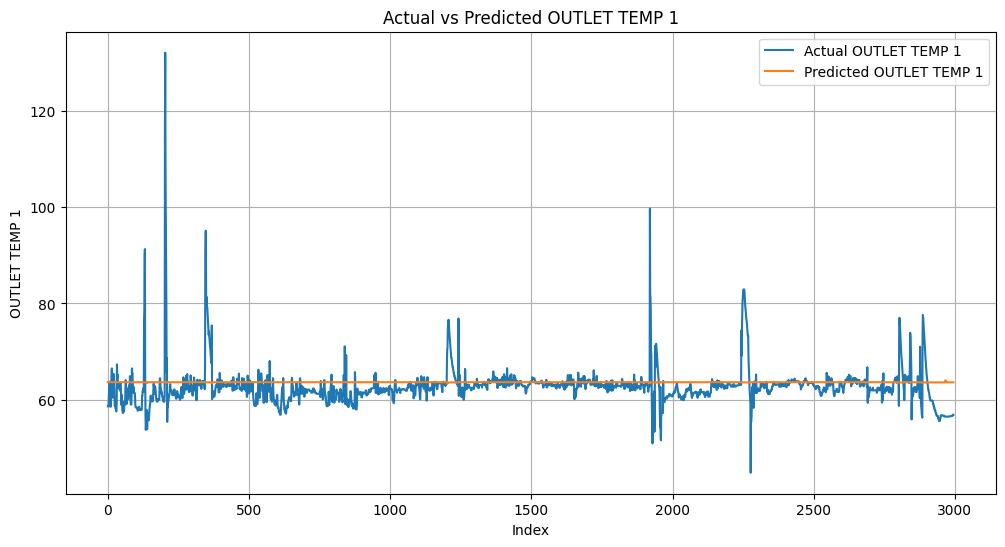

In [34]:
# Pilih fitur yang digunakan (kecuali "Date/Time" dan "OUTLET TEMP 2")
X = df_baru.drop(columns=["Date/Time", "OUTLET TEMP 1", "OUTLET TEMP 2"])  # Input features
y = df_baru["OUTLET TEMP 1"]  # Target yang ingin diprediksi

# Muat kembali model terbaik
best_model_loaded = joblib.load("Adaboost_Best.pkl")

# Prediksi nilai OUTLET TEMP 1
y_pred = best_model_loaded.predict(X)

# Plot hasil prediksi vs nilai asli
plt.figure(figsize=(12, 6))
plt.plot(y.values, label="Actual OUTLET TEMP 1")
plt.plot(y_pred, label="Predicted OUTLET TEMP 1")

# Tambahkan label dan judul
plt.xlabel("Index")
plt.ylabel("OUTLET TEMP 1")
plt.title("Actual vs Predicted OUTLET TEMP 1")
plt.legend()
plt.grid(True)
plt.show()

c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but ExtraTreesRegressor was fitted without feature names
  warnings.warn(


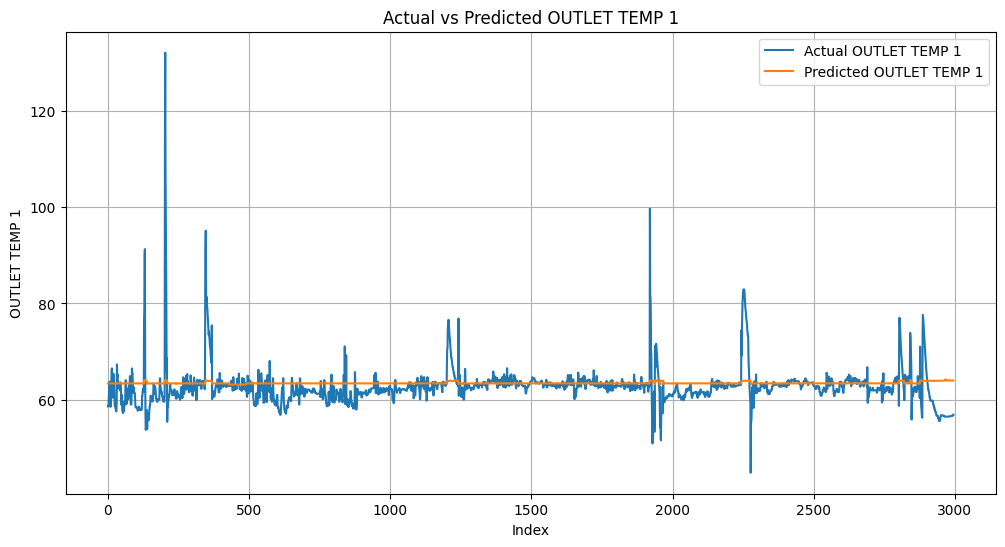

In [35]:
# Pilih fitur yang digunakan (kecuali "Date/Time" dan "OUTLET TEMP 2")
X = df_baru.drop(columns=["Date/Time", "OUTLET TEMP 1", "OUTLET TEMP 2"])  # Input features
y = df_baru["OUTLET TEMP 1"]  # Target yang ingin diprediksi

# Muat kembali model terbaik
best_model_loaded = joblib.load("ExtraTree_Best.pkl")

# Prediksi nilai OUTLET TEMP 1
y_pred = best_model_loaded.predict(X)

# Plot hasil prediksi vs nilai asli
plt.figure(figsize=(12, 6))
plt.plot(y.values, label="Actual OUTLET TEMP 1")
plt.plot(y_pred, label="Predicted OUTLET TEMP 1")

# Tambahkan label dan judul
plt.xlabel("Index")
plt.ylabel("OUTLET TEMP 1")
plt.title("Actual vs Predicted OUTLET TEMP 1")
plt.legend()
plt.grid(True)
plt.show()

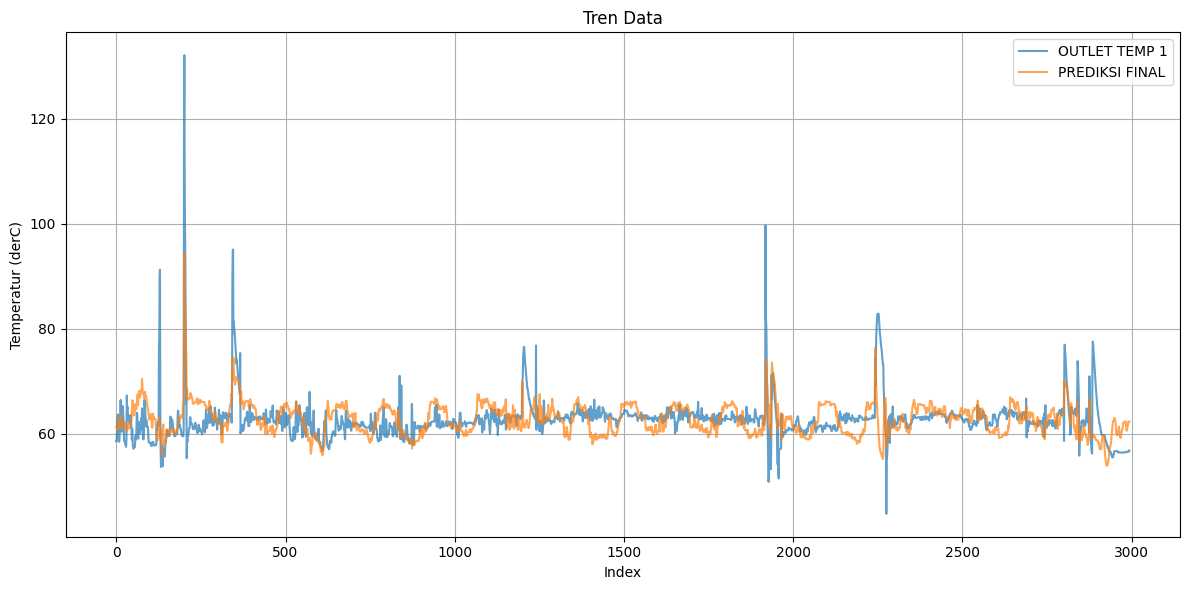

In [36]:
df_lagi = pd.read_excel("Databersih.xlsx")

# Memilih kolom yang akan ditampilkan
columns_to_plot = ['OUTLET TEMP 1', 'PREDIKSI FINAL']

# Memeriksa apakah kolom yang diperlukan ada dalam dataset
for col in columns_to_plot:
    if col not in df_lagi.columns:
        raise ValueError(f"Kolom '{col}' tidak ditemukan dalam dataset.")

# Membuat grafik tunggal
plt.figure(figsize=(12, 6))
for col in columns_to_plot:
    plt.plot(df_lagi.index, df_lagi[col], linestyle='-', label=col, alpha=0.7)

# Menambahkan judul dan label
plt.title("Tren Data")
plt.xlabel("Index")
plt.ylabel("Temperatur (derC)")
plt.legend()  # Menampilkan legenda untuk setiap kolom
plt.grid(True)  # Menambahkan grid untuk memudahkan pembacaan

# Menampilkan plot
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Baca file
df_lagi = pd.read_excel("Databersih.xlsx")

# Pilih kolom target & prediksi
columns_to_plot = ['OUTLET TEMP 1', 'LINEAR REGRESI']

# Pastikan kolom ada
for col in columns_to_plot:
    if col not in df_lagi.columns:
        raise ValueError(f"Kolom '{col}' tidak ditemukan dalam dataset.")

# Buang baris yang mengandung NaN
df_clean = df_lagi[columns_to_plot].dropna()

# Pisahkan target & prediksi
y_true = df_clean['OUTLET TEMP 1']
y_pred = df_clean['LINEAR REGRESI']

# Hitung metrik regresi
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("=== Evaluasi Model ===")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

=== Evaluasi Model (Setelah Hapus NaN) ===
MSE  : 10.2063
RMSE : 3.1947
MAE  : 1.9510
R²   : 0.3497
